In [54]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
# from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')

Load data

In [2]:
# Loading processed splits and weights from feature engineering notebook
train_df = pd.read_csv('../data/train_processed.csv')
val_df = pd.read_csv('../data/val_processed.csv')
test_df = pd.read_csv('../data/test_processed.csv')
w_train = pd.read_csv('../data/w_train.csv').squeeze()
w_val = pd.read_csv('../data/w_val.csv').squeeze()
w_test = pd.read_csv('../data/w_test.csv').squeeze()

print(f"Train: {train_df.shape}")
print(f"Val: {val_df.shape}")
print(f"Test: {test_df.shape}")

Train: (139666, 20)
Val: (29928, 20)
Test: (29929, 20)


Split X and y

In [42]:
# Separating features from label
X_train = train_df.drop(columns=['label'])
y_train = train_df['label']

X_val = val_df.drop(columns=['label'])
y_val = val_df['label']

X_test = test_df.drop(columns=['label'])
y_test = test_df['label']

print(f"Features: {X_train.columns.tolist()}")
print(f"Number of features: {X_train.shape[1]}")

Features: ['age', 'class of worker', 'education', 'marital stat', 'major occupation code', 'race', 'sex', 'full or part time employment stat', 'capital gains', 'capital losses', 'dividends from stocks', 'tax filer stat', 'detailed household summary in household', 'num persons worked for employer', 'citizenship', 'own business or self employed', "fill inc questionnaire for veteran's admin", 'veterans benefits', 'weeks worked in year']
Number of features: 19


# `Logistic Regression`

In [4]:
# Logistic Regression baseline
# class_weight='balanced' handles the 6% minority class

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train, sample_weight=w_train)

y_prob_lr = lr.predict_proba(X_val)[:, 1]
y_pred_lr = (y_prob_lr >= 0.2).astype(int)

print("=== Logistic Regression (threshold 0.2) ===")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

=== Logistic Regression (threshold 0.2) ===
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     28071
           1       0.06      1.00      0.12      1857

    accuracy                           0.06     29928
   macro avg       0.03      0.50      0.06     29928
weighted avg       0.00      0.06      0.01     29928

ROC-AUC: 0.8894853455198333


In [8]:
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1 = {f1:.4f}")

Threshold 0.3: F1 = 0.1168
Threshold 0.4: F1 = 0.1707
Threshold 0.5: F1 = 0.2764
Threshold 0.6: F1 = 0.3707
Threshold 0.7: F1 = 0.0000


In [9]:
for thresh in [0.55, 0.58, 0.60, 0.62, 0.65]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1 = {f1:.4f}")

Threshold 0.55: F1 = 0.3919
Threshold 0.58: F1 = 0.4417
Threshold 0.6: F1 = 0.3707
Threshold 0.62: F1 = 0.1901
Threshold 0.65: F1 = 0.0000


In [10]:
for thresh in [0.56, 0.57, 0.58, 0.59]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1 = {f1:.4f}")

Threshold 0.56: F1 = 0.3987
Threshold 0.57: F1 = 0.4290
Threshold 0.58: F1 = 0.4417
Threshold 0.59: F1 = 0.4273


In [45]:
# LR model version 2.0 

y_pred_lr = (y_prob_lr >= 0.58).astype(int)

print("=== Logistic Regression (threshold 0.58) ===")
print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

=== Logistic Regression (threshold 0.58) ===
              precision    recall  f1-score   support

           0       0.99      0.86      0.92     28071
           1       0.28      0.83      0.42      1857

    accuracy                           0.86     29928
   macro avg       0.64      0.85      0.67     29928
weighted avg       0.94      0.86      0.89     29928

ROC-AUC: 0.9311338908741041


In [48]:
cm_lr = confusion_matrix(y_val, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
# disp_lr.plot()
# plt.title('Logistic Regression Confusion Matrix')
# plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print("=== Logistic Regression ===")
print(f"True Negatives (correctly identified low earners): {tn}")
print(f"False Positives (predicted high, actually low - wasted spend): {fp}")
print(f"False Negatives (missed high earners - lost opportunity): {fn}")
print(f"True Positives (correctly identified high earners): {tp}")
print(f"\nOf every 100 people flagged as high earners: {tp/(tp+fp)*100:.0f} actually are")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

=== Logistic Regression ===
True Negatives (correctly identified low earners): 24187
False Positives (predicted high, actually low - wasted spend): 3884
False Negatives (missed high earners - lost opportunity): 310
True Positives (correctly identified high earners): 1547

Of every 100 people flagged as high earners: 28 actually are
Model catches 83% of all actual high earners


### Checking VIF values

In [12]:
vif_data = pd.DataFrame()
vif_data['feature'] = X_train.columns
vif_data['VIF'] = [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])]
print(vif_data.sort_values('VIF', ascending=False))

                                       feature        VIF
16  fill inc questionnaire for veteran's admin  22.693577
5                                         race  16.588355
13             num persons worked for employer  16.280595
17                           veterans benefits  15.181528
11                              tax filer stat  13.979178
18                        weeks worked in year  13.094420
1                              class of worker  10.376984
0                                          age  10.058030
12     detailed household summary in household   8.647414
3                                 marital stat   6.613618
2                                    education   4.383896
4                        major occupation code   3.663238
6                                          sex   2.022500
10                       dividends from stocks   1.300495
15               own business or self employed   1.214364
8                                capital gains   1.093242
9             

In [13]:
X_train_vif = X_train.drop(columns=["fill inc questionnaire for veteran's admin"])
vif_data2 = pd.DataFrame()
vif_data2['feature'] = X_train_vif.columns
vif_data2['VIF'] = [variance_inflation_factor(X_train_vif.values, i) for i in range(X_train_vif.shape[1])]
print(vif_data2.sort_values('VIF', ascending=False))

                                    feature        VIF
13          num persons worked for employer  16.278824
16                        veterans benefits  14.905432
11                           tax filer stat  13.979068
17                     weeks worked in year  12.995875
0                                       age   9.970950
1                           class of worker   9.377732
12  detailed household summary in household   8.647394
5                                      race   8.332832
3                              marital stat   6.603282
2                                 education   4.346936
4                     major occupation code   3.279342
6                                       sex   1.963772
10                    dividends from stocks   1.295547
15            own business or self employed   1.214101
8                             capital gains   1.091808
9                            capital losses   1.045869
7         full or part time employment stat        NaN
14        

In [14]:
X_train_vif2 = X_train_vif.drop(columns=['num persons worked for employer'])
vif_data3 = pd.DataFrame()
vif_data3['feature'] = X_train_vif2.columns
vif_data3['VIF'] = [variance_inflation_factor(X_train_vif2.values, i) for i in range(X_train_vif2.shape[1])]
print(vif_data3.sort_values('VIF', ascending=False))

                                    feature        VIF
15                        veterans benefits  13.778971
11                           tax filer stat  13.423432
0                                       age   9.711689
1                           class of worker   9.077683
12  detailed household summary in household   8.614847
5                                      race   8.326257
3                              marital stat   6.484404
16                     weeks worked in year   6.087606
2                                 education   4.340828
4                     major occupation code   3.266480
6                                       sex   1.963469
10                    dividends from stocks   1.295539
14            own business or self employed   1.202079
8                             capital gains   1.091804
9                            capital losses   1.045786
7         full or part time employment stat        NaN
13                              citizenship        NaN


In [15]:
X_train_vif3 = X_train_vif2.drop(columns=['veterans benefits'])
vif_data4 = pd.DataFrame()
vif_data4['feature'] = X_train_vif3.columns
vif_data4['VIF'] = [variance_inflation_factor(X_train_vif3.values, i) for i in range(X_train_vif3.shape[1])]
print(vif_data4.sort_values('VIF', ascending=False))

                                    feature        VIF
11                           tax filer stat  12.965034
12  detailed household summary in household   8.500527
1                           class of worker   8.451105
5                                      race   8.229289
0                                       age   6.838117
3                              marital stat   6.394093
15                     weeks worked in year   6.080838
2                                 education   4.177094
4                     major occupation code   3.251022
6                                       sex   1.963242
10                    dividends from stocks   1.284546
14            own business or self employed   1.198063
8                             capital gains   1.089816
9                            capital losses   1.045618
7         full or part time employment stat        NaN
13                              citizenship        NaN


In [16]:
X_train_vif4 = X_train_vif3.drop(columns=['tax filer stat'])
vif_data5 = pd.DataFrame()
vif_data5['feature'] = X_train_vif4.columns
vif_data5['VIF'] = [variance_inflation_factor(X_train_vif4.values, i) for i in range(X_train_vif4.shape[1])]
print(vif_data5.sort_values('VIF', ascending=False))

                                    feature       VIF
11  detailed household summary in household  8.334631
1                           class of worker  8.330923
5                                      race  8.178848
0                                       age  6.813028
14                     weeks worked in year  5.156804
2                                 education  4.018239
4                     major occupation code  3.228056
3                              marital stat  3.205328
6                                       sex  1.956013
10                    dividends from stocks  1.282319
13            own business or self employed  1.195882
8                             capital gains  1.088843
9                            capital losses  1.044772
7         full or part time employment stat       NaN
12                              citizenship       NaN


`Columns dropped for multicollinearity:`

* fill inc questionnaire for veteran's admin
* num persons worked for employer
* veterans benefits
* tax filer stat

In [26]:
cols_to_drop_vif = [
    "fill inc questionnaire for veteran's admin",
    'num persons worked for employer',
    'veterans benefits',
    'tax filer stat'
]

X_train_lr = X_train.drop(columns=cols_to_drop_vif)
X_val_lr = X_val.drop(columns=cols_to_drop_vif)

lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train_lr, y_train, sample_weight=w_train)

y_prob_lr = lr.predict_proba(X_val_lr)[:, 1]
y_pred_lr = (y_prob_lr >= 0.55).astype(int)

print(classification_report(y_val, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95     28071
           1       0.35      0.58      0.44      1857

    accuracy                           0.91     29928
   macro avg       0.66      0.75      0.69     29928
weighted avg       0.93      0.91      0.92     29928

ROC-AUC: 0.8945767125198936


In [27]:
for C in [0.01, 0.1, 1, 10, 100]:
    lr_test = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=C)
    lr_test.fit(X_train, y_train, sample_weight=w_train)
    y_prob = lr_test.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.55).astype(int)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    print(f"C={C}: F1={f1:.4f}, AUC={auc:.4f}")

C=0.01: F1=0.0000, AUC=0.8837
C=0.1: F1=0.0000, AUC=0.8843
C=1: F1=0.3919, AUC=0.8895
C=10: F1=0.3705, AUC=0.9081
C=100: F1=0.4037, AUC=0.9257


In [28]:
for C in [100, 500, 1000, 5000]:
    lr_test = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=C)
    lr_test.fit(X_train, y_train, sample_weight=w_train)
    y_prob = lr_test.predict_proba(X_val)[:, 1]
    y_pred = (y_prob >= 0.55).astype(int)
    f1 = f1_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_prob)
    print(f"C={C}: F1={f1:.4f}, AUC={auc:.4f}")

C=100: F1=0.4037, AUC=0.9257
C=500: F1=0.4160, AUC=0.9311
C=1000: F1=0.4155, AUC=0.9322
C=5000: F1=0.4160, AUC=0.9330


In [29]:
lr_best = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=500)
lr_best.fit(X_train, y_train, sample_weight=w_train)
y_prob_lr = lr_best.predict_proba(X_val)[:, 1]

for thresh in [0.50, 0.52, 0.54, 0.55, 0.56, 0.58, 0.60]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.5: F1=0.3897
Threshold 0.52: F1=0.4015
Threshold 0.54: F1=0.4108
Threshold 0.55: F1=0.4160
Threshold 0.56: F1=0.4192
Threshold 0.58: F1=0.4245
Threshold 0.6: F1=0.4342


In [30]:
for thresh in [0.60, 0.62, 0.64, 0.65, 0.66, 0.68, 0.70]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.6: F1=0.4342
Threshold 0.62: F1=0.4421
Threshold 0.64: F1=0.4513
Threshold 0.65: F1=0.4531
Threshold 0.66: F1=0.4584
Threshold 0.68: F1=0.4673
Threshold 0.7: F1=0.4797


In [31]:
for thresh in [0.70, 0.72, 0.74, 0.75, 0.76, 0.78, 0.80]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.7: F1=0.4797
Threshold 0.72: F1=0.4937
Threshold 0.74: F1=0.5063
Threshold 0.75: F1=0.5067
Threshold 0.76: F1=0.5093
Threshold 0.78: F1=0.5109
Threshold 0.8: F1=0.5138


In [32]:
for thresh in [0.80, 0.82, 0.84, 0.85, 0.86, 0.88, 0.80]:
    y_pred = (y_prob_lr >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.8: F1=0.5138
Threshold 0.82: F1=0.5163
Threshold 0.84: F1=0.5146
Threshold 0.85: F1=0.5118
Threshold 0.86: F1=0.5051
Threshold 0.88: F1=0.4993
Threshold 0.8: F1=0.5138


# Final Model for Logistic Regression

In [33]:
y_pred_lr_final = (y_prob_lr >= 0.80).astype(int)
print(classification_report(y_val, y_pred_lr_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_lr))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96     28071
           1       0.45      0.59      0.51      1857

    accuracy                           0.93     29928
   macro avg       0.71      0.77      0.74     29928
weighted avg       0.94      0.93      0.93     29928

ROC-AUC: 0.9311338908741041


# `GradientBoostingClassifier`

In [5]:
# Gradient Boosting - handles non-linear relationships better than LR
# class_weight not available, using sample_weight instead
gb = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb.fit(X_train, y_train, sample_weight=w_train)

y_prob_gb = gb.predict_proba(X_val)[:, 1]
y_pred_gb = (y_prob_gb >= 0.2).astype(int)

print("=== Gradient Boosting (threshold 0.2) ===")
print(classification_report(y_val, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_gb))

=== Gradient Boosting (threshold 0.2) ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     28071
           1       0.44      0.66      0.53      1857

    accuracy                           0.93     29928
   macro avg       0.71      0.80      0.74     29928
weighted avg       0.94      0.93      0.93     29928

ROC-AUC: 0.9371333425683206


In [34]:
gb = GradientBoostingClassifier(random_state=42, n_estimators=100)
gb.fit(X_train, y_train, sample_weight=w_train)

y_prob_gb = gb.predict_proba(X_val)[:, 1]

# Find best threshold first
for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob_gb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.1: F1=0.4774
Threshold 0.2: F1=0.5263
Threshold 0.3: F1=0.5385
Threshold 0.4: F1=0.5111
Threshold 0.5: F1=0.4761


In [35]:
for thresh in [0.25, 0.28, 0.30, 0.32, 0.35]:
    y_pred = (y_prob_gb >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.25: F1=0.5371
Threshold 0.28: F1=0.5417
Threshold 0.3: F1=0.5385
Threshold 0.32: F1=0.5355
Threshold 0.35: F1=0.5369


## Best Gradient Boosting Model

In [36]:
y_pred_gb_final = (y_prob_gb >= 0.28).astype(int)
print(classification_report(y_val, y_pred_gb_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_gb))

              precision    recall  f1-score   support

           0       0.97      0.96      0.97     28071
           1       0.51      0.57      0.54      1857

    accuracy                           0.94     29928
   macro avg       0.74      0.77      0.75     29928
weighted avg       0.94      0.94      0.94     29928

ROC-AUC: 0.9371333425683206


### Confusion Matrix comparison

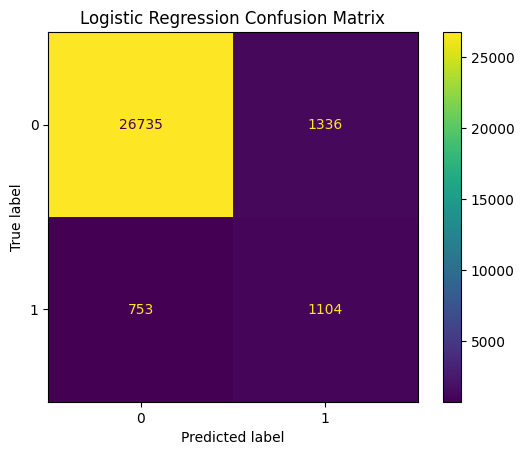

=== Logistic Regression ===
True Negatives (correctly identified low earners): 26735
False Positives (predicted high, actually low - wasted spend): 1336
False Negatives (missed high earners - lost opportunity): 753
True Positives (correctly identified high earners): 1104

Of every 100 people flagged as high earners: 45 actually are
Model catches 59% of all actual high earners


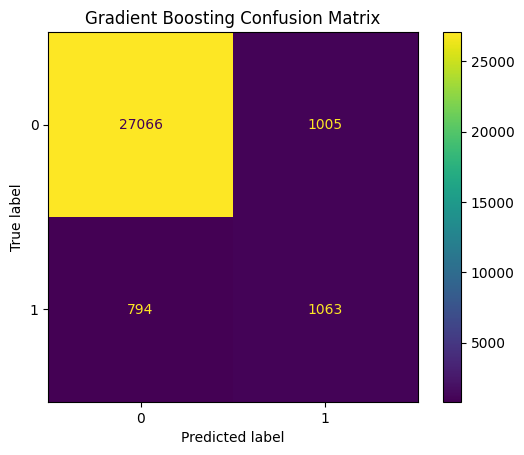


=== Gradient Boosting ===
True Negatives (correctly identified low earners): 27066
False Positives (predicted high, actually low - wasted spend): 1005
False Negatives (missed high earners - lost opportunity): 794
True Positives (correctly identified high earners): 1063

Of every 100 people flagged as high earners: 51 actually are
Model catches 57% of all actual high earners


In [41]:
# Logistic Regression Confusion Matrix
cm_lr = confusion_matrix(y_val, y_pred_lr_final)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_lr.ravel()
print("=== Logistic Regression ===")
print(f"True Negatives (correctly identified low earners): {tn}")
print(f"False Positives (predicted high, actually low - wasted spend): {fp}")
print(f"False Negatives (missed high earners - lost opportunity): {fn}")
print(f"True Positives (correctly identified high earners): {tp}")
print(f"\nOf every 100 people flagged as high earners: {tp/(tp+fp)*100:.0f} actually are")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

# Gradient Boosting Confusion Matrix
cm_gb = confusion_matrix(y_val, y_pred_gb_final)
disp_gb = ConfusionMatrixDisplay(confusion_matrix=cm_gb)
disp_gb.plot()
plt.title('Gradient Boosting Confusion Matrix')
plt.show()

tn, fp, fn, tp = cm_gb.ravel()
print("\n=== Gradient Boosting ===")
print(f"True Negatives (correctly identified low earners): {tn}")
print(f"False Positives (predicted high, actually low - wasted spend): {fp}")
print(f"False Negatives (missed high earners - lost opportunity): {fn}")
print(f"True Positives (correctly identified high earners): {tp}")
print(f"\nOf every 100 people flagged as high earners: {tp/(tp+fp)*100:.0f} actually are")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

# Gridsearch for Gradient Boost

In [49]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

gb_tuned = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    params,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

gb_tuned.fit(X_train, y_train, sample_weight=w_train)
print(f"Best params: {gb_tuned.best_params_}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}


In [50]:
best_gb = gb_tuned.best_estimator_

y_prob_gb_tuned = best_gb.predict_proba(X_val)[:, 1]

# Find best threshold
for thresh in [0.25, 0.28, 0.30, 0.32, 0.35]:
    y_pred = (y_prob_gb_tuned >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.25: F1=0.5417
Threshold 0.28: F1=0.5446
Threshold 0.3: F1=0.5477
Threshold 0.32: F1=0.5432
Threshold 0.35: F1=0.5367


In [51]:
for thresh in [0.28, 0.29, 0.30, 0.31, 0.32]:
    y_pred = (y_prob_gb_tuned >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.28: F1=0.5446
Threshold 0.29: F1=0.5456
Threshold 0.3: F1=0.5477
Threshold 0.31: F1=0.5448
Threshold 0.32: F1=0.5432


In [52]:
y_pred_gb_tuned_final = (y_prob_gb_tuned >= 0.30).astype(int)
print(classification_report(y_val, y_pred_gb_tuned_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_gb_tuned))

cm = confusion_matrix(y_val, y_pred_gb_tuned_final)
tn, fp, fn, tp = cm.ravel()
print(f"\nOf every 100 people flagged as high earners: {tp/(tp+fp)*100:.0f} actually are")
print(f"Model catches {tp/(tp+fn)*100:.0f}% of all actual high earners")

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     28071
           1       0.53      0.57      0.55      1857

    accuracy                           0.94     29928
   macro avg       0.75      0.77      0.76     29928
weighted avg       0.94      0.94      0.94     29928

ROC-AUC: 0.9373941916304351

Of every 100 people flagged as high earners: 53 actually are
Model catches 57% of all actual high earners


# Random Forest

In [53]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100, n_jobs=-1)
rf.fit(X_train, y_train, sample_weight=w_train)

y_prob_rf = rf.predict_proba(X_val)[:, 1]

for thresh in [0.1, 0.2, 0.3, 0.4, 0.5]:
    y_pred = (y_prob_rf >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.1: F1=0.3625
Threshold 0.2: F1=0.3793
Threshold 0.3: F1=0.3982
Threshold 0.4: F1=0.4110
Threshold 0.5: F1=0.4249


In [55]:
for thresh in [0.5, 0.55, 0.6, 0.65, 0.7]:
    y_pred = (y_prob_rf >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")

Threshold 0.5: F1=0.4249
Threshold 0.55: F1=0.4297
Threshold 0.6: F1=0.4302
Threshold 0.65: F1=0.4324
Threshold 0.7: F1=0.4414


In [56]:
for thresh in [0.70, 0.72, 0.74, 0.75, 0.76, 0.78, 0.80]:
    y_pred = (y_prob_rf >= thresh).astype(int)
    f1 = f1_score(y_val, y_pred)
    print(f"Threshold {thresh}: F1={f1:.4f}")
    

Threshold 0.7: F1=0.4414
Threshold 0.72: F1=0.4396
Threshold 0.74: F1=0.4353
Threshold 0.75: F1=0.4343
Threshold 0.76: F1=0.4349
Threshold 0.78: F1=0.4268
Threshold 0.8: F1=0.4211


In [57]:
y_pred_rf_final = (y_prob_rf >= 0.70).astype(int)
print(classification_report(y_val, y_pred_rf_final))
print("ROC-AUC:", roc_auc_score(y_val, y_prob_rf))

              precision    recall  f1-score   support

           0       0.96      0.97      0.96     28071
           1       0.45      0.43      0.44      1857

    accuracy                           0.93     29928
   macro avg       0.71      0.70      0.70     29928
weighted avg       0.93      0.93      0.93     29928

ROC-AUC: 0.8750450982562163


## Save Best Performing Models

In [59]:


joblib.dump(best_gb, '../output/models/gradient_boosting_tuned.pkl')
joblib.dump(lr_best, '../output/models/logistic_regression.pkl')
joblib.dump(rf, '../output/models/random_forest.pkl')

print("All models saved!")

All models saved!


In [61]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gb_cv = GradientBoostingClassifier(
    learning_rate=0.05, 
    max_depth=5, 
    n_estimators=200, 
    subsample=1.0,
    random_state=42
)

scores = cross_val_score(gb_cv, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"F1 scores per fold: {scores.round(4)}")
print(f"Mean F1: {scores.mean():.4f}")
print(f"Std F1: {scores.std():.4f}")

F1 scores per fold: [0.4332 0.4623 0.4585 0.464  0.4634]
Mean F1: 0.4563
Std F1: 0.0117


In [62]:
from sklearn.linear_model import LogisticRegression

lr_cv = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=500)

scores_lr = cross_val_score(lr_cv, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"LR F1 scores per fold: {scores_lr.round(4)}")
print(f"LR Mean F1: {scores_lr.mean():.4f}")
print(f"LR Std F1: {scores_lr.std():.4f}")

print()

scores_gb = cross_val_score(gb_cv, X_train, y_train, cv=skf, scoring='f1', n_jobs=-1)
print(f"GB F1 scores per fold: {scores_gb.round(4)}")
print(f"GB Mean F1: {scores_gb.mean():.4f}")
print(f"GB Std F1: {scores_gb.std():.4f}")

LR F1 scores per fold: [0.3843 0.3941 0.3968 0.3901 0.3943]
LR Mean F1: 0.3919
LR Std F1: 0.0044

GB F1 scores per fold: [0.4332 0.4623 0.4585 0.464  0.4634]
GB Mean F1: 0.4563
GB Std F1: 0.0117


In [63]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import numpy as np

def cv_with_threshold(model, X, y, threshold, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
        X_fold_train, X_fold_val = X.iloc[train_idx], X.iloc[val_idx]
        y_fold_train, y_fold_val = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_fold_train, y_fold_train)
        y_prob = model.predict_proba(X_fold_val)[:, 1]
        y_pred = (y_prob >= threshold).astype(int)
        f1 = f1_score(y_fold_val, y_pred)
        f1_scores.append(f1)
        print(f"Fold {fold+1}: F1={f1:.4f}")
    
    print(f"\nMean F1: {np.mean(f1_scores):.4f}")
    print(f"Std F1: {np.std(f1_scores):.4f}")
    return f1_scores

print("=== Logistic Regression (threshold 0.80) ===")
lr_cv = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000, C=500)
cv_with_threshold(lr_cv, X_train, y_train, threshold=0.80)

print("\n=== Gradient Boosting (threshold 0.30) ===")
gb_cv = GradientBoostingClassifier(learning_rate=0.05, max_depth=5, n_estimators=200, subsample=1.0, random_state=42)
cv_with_threshold(gb_cv, X_train, y_train, threshold=0.30)

=== Logistic Regression (threshold 0.80) ===
Fold 1: F1=0.4948
Fold 2: F1=0.5097
Fold 3: F1=0.5010
Fold 4: F1=0.5115
Fold 5: F1=0.5111

Mean F1: 0.5056
Std F1: 0.0066

=== Gradient Boosting (threshold 0.30) ===
Fold 1: F1=0.5090
Fold 2: F1=0.5337
Fold 3: F1=0.5278
Fold 4: F1=0.5318
Fold 5: F1=0.5226

Mean F1: 0.5250
Std F1: 0.0089


[0.5090002769315979,
 0.5337406276034435,
 0.5278236914600551,
 0.5318454001088732,
 0.5225531914893617]